In [2]:
import sys
sys.path.append('../')
from utils_models import *

/home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/qiskit_dynamics/dispatch/backends/jax.py:34: UserWarning: The functionality in the perturbation module of Qiskit Dynamics requires a JAX version <= 0.4.6, due to a bug in JAX versions > 0.4.6. For versions 0.4.4, 0.4.5, and 0.4.6, using the perturbation module functionality requires setting os.environ['JAX_JIT_PJIT_API_MERGE'] = '0' before importing JAX or Dynamics.
  warnings.warn(


In [26]:
max_ql = 14
max_ol = 40
system = FluxoniumOscillatorSystem(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2',
    )

tot_time = 810
tlist = np.linspace(0, tot_time, tot_time)

with open('../pickles/mesolve_wd1649_unitary_large_dim.pkl', 'rb') as file:
    results = pickle.load(file)

In [5]:
lists = []
for ql in [0,1,2,3]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 0
        for q in range(system.qbt.truncated_dim):
            if q != ql:
                for o in range(system.osc.truncated_dim):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum += expectation_value

        pop_list.append(pop_sum)
    # print(pop_list)
    lists.append(pop_list)

with open('../pickles/mesolve_wd1649_unitary_large_dim_leakage_list.pkl', 'wb') as file:
    pickle.dump(lists, file)
    

Text(0.5, 0, 't (ns)')

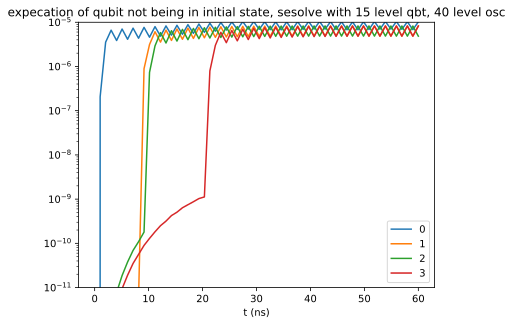

In [ ]:
with open('../pickles/mesolve_wd1649_unitary_large_dim_leakage_list.pkl', 'rb') as file:
    lists = pickle.load(file)
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.ylim(1e-11,1e-5)
plt.legend()
plt.title('expecation of qubit not being in initial state, sesolve with 14 level qbt, 40 level osc')
plt.xlabel('t (ns)')

In [32]:
interactive_heatmap(results[0], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=782), Output(…

state 0: 0-45 lvl, 7-32lvl          => 77lvl

state 3: 3-40lvl, 12-20lvl          => 60 lvl

state 1: 1-18 lvl, 10-8lvl          => 26 lvl

state 2: 2-18 lvl, 9-8 lvl, 11- 8lvl => 34 lvl  => 70 lvl